# Physiognomy Project

This project explores how Vision Language Models (VLMs) and Retrieval-Augmented Generation (RAG) can be combined to analyze facial morphology and retrieve relevant descriptions from a physiognomy reference book.

## Project Pipeline

1. Face Detection & Landmark Extraction
2. Face Part Segmentation (Forehead, Eyes, Eyebrows, Nose, Mouth, Jaw/Chin, Ears)
3. Vision-Language Analysis using Gemini
4. Structured JSON Feature Extraction
5. Semantic Retrieval using FAISS and Sentence Transformers
6. Evidence Collection from the Reference Book
7. Final Report Generation

## Example Workflow

Face Image
→ Face Parts Extraction
→ Visual Feature Description
→ Semantic Search in Knowledge Base
→ Retrieved Evidence
→ Final Face Reading Report

## Technologies

* Python
* OpenCV
* MediaPipe
* Gemini Vision Models
* Sentence Transformers
* FAISS
* EasyOCR
* Retrieval-Augmented Generation (RAG)

## Disclaimer

This project is intended for educational and research purposes only. The generated descriptions and retrieved interpretations originate from the source reference material and should not be considered scientific, psychological, medical, or personality assessments.

## Author

Yasmeen Asaad
Machine Learning Engineer


# 1) Install Dependencies

In [2]:
!pip install mediapipe opencv-python easyocr \
             pymupdf sentence-transformers \
             faiss-cpu google-generativeai -q
print("All dependencies installed sussessfully")

All dependencies installed sussessfully


# 2) Clone GitHub Repo

In [6]:
import os 
import sys

REPO_URL  = "https://github.com/yasmeen-asaad/face-physiognomy-project.git"
REPO_NAME = "face-physiognomy-project"

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}
else:
    %cd {REPO_NAME}
    !git pull
    %cd /kaggle/working

sys.path.insert(0, f"/kaggle/working/{REPO_NAME}/src")
print("Repo is ready")

/kaggle/working/face-physiognomy-project
Already up to date.
/kaggle/working
Repo is ready


# 3) Imports

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import display, Markdown

from face_detector import FaceDetectorValidator, Config
from face_part_extractor import FacePartExtractor, PaddingConfig
from face_descriper import FaceDescriptor
from rag_retriever import PhysiognomyRetriever
from report_generator import ReportGenerator

print("All imports successful")

2026-06-17 08:57:28.243974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781686648.286606    1495 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781686648.300092    1495 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781686648.353330    1495 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781686648.353476    1495 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781686648.353479    1495 computation_placer.cc:177] computation placer alr

All imports successful


# 4) Config  

In [8]:
# Paths 
IMAGE_PATH  = "/kaggle/input/datasets/yasmeenasaad/images-for-testinmg/9c7a12bd-96b0-4407-ae6f-a0bb8e2913db.jpg"
INDEX_PATH   = "/kaggle/input/datasets/yasmeenasaad/rag-index/index.faiss"
CHUNK_PATH = "/kaggle/input/datasets/yasmeenasaad/rag-index/chunks.pkl"
OUTPUT_DIR  = "/kaggle/working/outputs"

# Flags
BUILD_RAG = False
USE_GPU = False 

# USed Models Name 
descriptor_model_name = "gemini-flash-lite-latest"#"gemini-2.0-flash-lite" #"gemini-2.5-flash"

# 5) Build RAG Index (Optional)

In [9]:
if BUILD_RAG:
    from rag_builder import RAGBuilder

    print("Building RAG index from book PDF")
    builder = RAGBuilder(pdf_path   = BOOK_PATH,output_dir = f"{OUTPUT_DIR}/rag_index",
                         start_page = 11,end_page   = 128,ocr_gpu = USE_GPU)
    stats = builder.build()

    # Update INDEX_DIR to the newly built index
    INDEX_DIR = f"{OUTPUT_DIR}/rag_index"

else:
    print("Skipping RAG build, using existing index")

Skipping RAG build, using existing index


# 6) Part 1: Face Detection & Validation

_______________________________________
Part 1, Face Detection & Validation
_______________________________________
MediaPipe FaceLandmarker initialized.

Status     : valid
Valid      : True
Message    : Valid face detected. Ready for physiognomy analysis.


W0000 00:00:1781686690.193717    1599 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781686690.211302    1603 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781686690.246835    1603 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


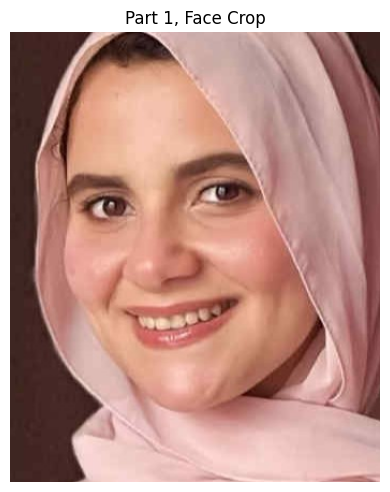

In [10]:
print("_______________________________________")
print("Part 1, Face Detection & Validation")
print("_______________________________________")

detector = FaceDetectorValidator()
result   = detector.process(IMAGE_PATH)

print(f"\nStatus     : {result.status.value}")
print(f"Valid      : {result.is_valid}")
print(f"Message    : {result.message}")

if not result.is_valid:
    print("Image is not good becasue: ", result.expression_scores)

#print(f"Face bbox : {result.face_bbox}")
#print(f"Crop size : {result.face_crop.shape[1]}×{result.face_crop.shape[0]} px")
#print(f"Landmarks : {len(result.crop_landmarks)} points")

# Show face crop
plt.figure(figsize=(4, 5))
plt.imshow(cv2.cvtColor(result.face_crop, cv2.COLOR_BGR2RGB))
plt.title("Part 1, Face Crop")
plt.axis("off")
plt.tight_layout()
plt.show()

# 7) Part 2: Face Parts Extraction

_______________________________________
Part 2, Face Parts Extraction
_______________________________________
_______________ Summary Table _______________
whole_face      250×308         1.0
forehead        230×123         1.0
eyebrows        306×64          1.0
eyes            244×50          1.0
nose            87×108          1.0
mouth           162×66          1.0
jaw_chin        254×203         1.0
ears            245×91          0.4


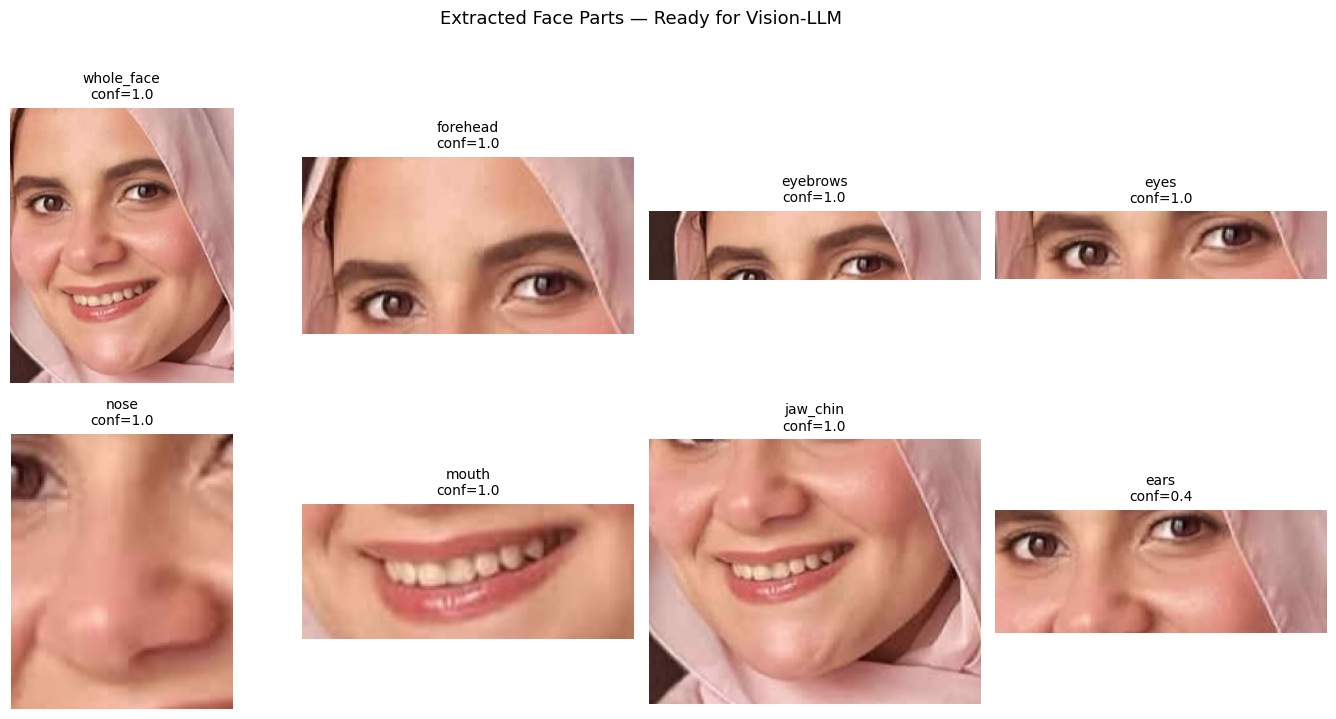

'\nfor name, part in parts_dict.items():\n    cv2.imwrite(f"{OUTPUT_DIR}/{name}.jpg", part.image)\nprint(f"Crops saved to {OUTPUT_DIR}/")\n'

In [13]:
print("_______________________________________")
print("Part 2, Face Parts Extraction")
print("_______________________________________")

extractor = FacePartExtractor(face_crop = result.face_crop, crop_landmarks = result.crop_landmarks,padding = PaddingConfig())
all_parts = extractor.extract_all_parts(include_ears=True)

# Summary table
print("_______________ Summary Table _______________")
for name, part in all_parts.to_dict().items():
    if part is not None:
        h, w = part.image.shape[:2]
        print(f"{name:<15} {str(w)+'×'+str(h):<15} {part.confidence_score:.1f}")
    else:
        print(f"{name:<15} {'FAILED':<15} -")
        
# Visualise all parts

def show_all_parts(all_parts):
    parts_dict   = all_parts.valid_parts()
    region_names = list(parts_dict.keys())
    n = len(region_names)
 
    cols = 4
    rows = (n + cols - 1) // cols
 
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes      = axes.flatten()
 
    for i, name in enumerate(region_names):
        part = parts_dict[name]
        img_rgb = cv2.cvtColor(part.image, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        conf_label = f"conf={part.confidence_score:.1f}"
        axes[i].set_title(f"{name}\n{conf_label}", fontsize=10)
        axes[i].axis("off")
 
        # Red border for low-confidence regions
        if part.confidence_score < 0.8:
            for spine in axes[i].spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(3)
 
    # Hide empty subplot slots
    for j in range(len(region_names), len(axes)):
        axes[j].set_visible(False)
 
    plt.suptitle("Extracted Face Parts — Ready for Vision-LLM", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
 
 
show_all_parts(all_parts)


# Save crops
"""
for name, part in parts_dict.items():
    cv2.imwrite(f"{OUTPUT_DIR}/{name}.jpg", part.image)
print(f"Crops saved to {OUTPUT_DIR}/")
"""

# 8) Part 3: VLM Description (Gemini Flash)


In [14]:
# Put your google api key 
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("GOOGLE_API_KEY")

In [15]:
describer = FaceDescriptor(api_key=api_key, model_name=descriptor_model_name) 
descriptions = describer.describe_all_parts(all_parts)

for region, desc in descriptions.items():
    status = "Sucess" if desc.success else "Failed"
    tokens = desc.tokens_used if desc.success else "-"
    print(f"{region:<15} {status:<10} {tokens}")



# Show one example ex (nose)
if "nose" in descriptions and descriptions["nose"].success:
    print("Example, Nose description:")
    print(json.dumps(descriptions["nose"].features_json, indent=2))

# Save descriptions
"""
desc_output = {k: v.features_json for k, v in descriptions.items() if v.success}
with open(f"{OUTPUT_DIR}/descriptions.json", "w") as f:
    json.dump(desc_output, f, indent=2)
print(f"Descriptions saved to {OUTPUT_DIR}/descriptions.json")
"""

Model gemini-flash-lite-latest is loaded successfully
[1/8] Describing: whole_face......
success, (2091 tokens)
[2/8] Describing: forehead......
success, (1617 tokens)
[3/8] Describing: eyebrows......
success, (1722 tokens)
[4/8] Describing: eyes......
success, (2154 tokens)
[5/8] Describing: nose......
success, (1825 tokens)
[6/8] Describing: mouth......
success, (1710 tokens)
[7/8] Describing: jaw_chin......
success, (1926 tokens)
[8/8] ears is skipped as it has low confidence: 0.4
whole_face      Sucess     2091
forehead        Sucess     1617
eyebrows        Sucess     1722
eyes            Sucess     2154
nose            Sucess     1825
mouth           Sucess     1710
jaw_chin        Sucess     1926
Example, Nose description:
{
  "nose_size_shape": {
    "value": "medium",
    "confidence": 0.8,
    "description": "Moderately sized nose with a rounded structure."
  },
  "nose_ridge": {
    "value": "straight",
    "confidence": 0.7,
    "description": "The bridge appears relatively

'\ndesc_output = {k: v.features_json for k, v in descriptions.items() if v.success}\nwith open(f"{OUTPUT_DIR}/descriptions.json", "w") as f:\n    json.dump(desc_output, f, indent=2)\nprint(f"Descriptions saved to {OUTPUT_DIR}/descriptions.json")\n'

# 9) Part 4: RAG Retrieval

In [16]:
print("_______________________________________")
print("PART 4, RAG Retrieval from Book")
print("_______________________________________")
retriever = PhysiognomyRetriever(index_path  = INDEX_PATH, chunks_path = CHUNK_PATH)
all_evidence = retriever.search_all_parts(descriptions, top_k=3)

# Show one example
print("Example: Nose evidence ──")
nose_ev = all_evidence.get("nose", {})
print(f"Query : {nose_ev.get('query', 'N/A')}")
print(f"Results : {len(nose_ev.get('results', []))} passages")
for r in nose_ev.get("results", []):
    print(f"[Page {r['page']} | relevance {r['score']:.0%}]")
    print(f" {r['content']}")


# Save evidence
"""
with open(f"{OUTPUT_DIR}/evidence.json", "w") as f:
    json.dump(all_evidence, f, indent=2)# Convert to serializable format
    
print(f"Evidence is saved sucessfully in {OUTPUT_DIR}/evidence.json")
"""

_______________________________________
PART 4, RAG Retrieval from Book
_______________________________________


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded 258 chunks
 Searching: whole_face
 sucess query: 'round face shape whole face with oval face type an'
 Searching: forehead
 sucess query: 'oval forehead shapes forehead with average forehea'
 Searching: eyebrows
 sucess query: 'arched eyebrows shape eyebrows with low eyebrows p'
 Searching: eyes
 sucess query: 'average eyes spacing eyes with neutral eyes angle '
 Searching: nose
 sucess query: 'medium nose size shape nose with straight nose rid'
 Searching: mouth
 sucess query: 'average mouth size mouth with upward mouth angle a'
 Searching: jaw_chin
 sucess query: 'rounded jaw shape jaw chin with moderate jaw width'
Example: Nose evidence ──
Query : medium nose size shape nose with straight nose ridge and average nose width and rounded nose tip size shape
Results : 3 passages
[Page 27 | relevance 54%]
 You get down to business and get the job done. You are not afraid of hard work, and have an exceptional ability to handle the boring details that would be difficult for most peop

'\nwith open(f"{OUTPUT_DIR}/evidence.json", "w") as f:\n    json.dump(all_evidence, f, indent=2)# Convert to serializable format\n    \nprint(f"Evidence is saved sucessfully in {OUTPUT_DIR}/evidence.json")\n'

# 10) Part 5: Generate Final Report

In [17]:
print("_______________________________________")
print("Part 5, Final Physiognomy Report")
print("_______________________________________")

generator = ReportGenerator(api_key=api_key, model_name=descriptor_model_name) 
report = generator.generate(all_evidence)
if report.success:
    print(f" Report is generated ({report.tokens_used} tokens)")
    print("_" * 50)
    print(report.report_text)
    print("_" * 50)
    
    # Save report
    """
    report_path = f"{OUTPUT_DIR}/physiognomy_report.txt"
    generator.save(report, report_path)
    print(f"Report is saved at {report_path}")
    """
else:
    print(f"Report failed: {report.error}")

_______________________________________
Part 5, Final Physiognomy Report
_______________________________________
ReportGenerator ready — model: gemini-flash-lite-latest
 Report is generated (2482 tokens)
__________________________________________________
### Physiognomy Personality Report

This report provides a personality analysis based on the provided visual observations and established physiognomic principles.

#### **Whole Face**
The subject possesses a round, oval-shaped face with a frontal profile and a rounded chin. No specific book evidence was provided for these general features; therefore, no personality insights are drawn for the face shape as a whole.

#### **Forehead**
The subject has an oval forehead of average height and width. The analysis reveals a complex thought process: while there is a tendency to embrace rules and certainty, the roundness of the forehead indicates a strong desire for originality and creative problem-solving. The subject likely prefers being prese

# 11) Full Summary Dashboard

In [18]:
print("_______________________________________")
print("PIPELINE SUMMARY")
print("_______________________________________")
summary = {
    "Part 1 — Detection"   : "✓" if result.is_valid else "✗",
    "Part 2 — Extraction"  : f"✓ {len(parts_dict)} regions",
    "Part 3 — Description" : f"✓ {sum(1 for d in descriptions.values() if d.success)}/{len(descriptions)} regions",
    "Part 4 — RAG"         : f"✓ {len(all_evidence)} regions searched",
    "Part 5 — Report"      : "✓ Generated" if report.success else "✗ Failed",
    }

for step, status in summary.items():
    print(f"  {step:<25} {status}")

print(f"\nOutputs saved to: {OUTPUT_DIR}/")
print("  ├── *.jpg              (region crops)")
print("  ├── descriptions.json  (VLM visual analysis)")
print("  ├── evidence.json      (RAG book passages)")
print("  └── physiognomy_report.txt  (final report)")

_______________________________________
PIPELINE SUMMARY
_______________________________________
  Part 1 — Detection        ✓
  Part 2 — Extraction       ✓ 8 regions
  Part 3 — Description      ✓ 7/7 regions
  Part 4 — RAG              ✓ 7 regions searched
  Part 5 — Report           ✓ Generated

Outputs saved to: /kaggle/working/outputs/
  ├── *.jpg              (region crops)
  ├── descriptions.json  (VLM visual analysis)
  ├── evidence.json      (RAG book passages)
  └── physiognomy_report.txt  (final report)
